# Intro

This approach uses reinforcement learning to enable the model to learn trading strategies based on the data provided, without being explicitly told what indicators to use. By refining the features, reward function, and hyperparameters, you can improve the performance of the trading strategy.









In [ ]:
pip install -q yfinance stable-baselines3 shimmy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 16.1 MB/s eta 0:00:00


In [ ]:
import os, time, yfinance, pickle
import pandas as pd
# import quandl
import numpy as np
import matplotlib.pyplot as plt
import gym
import numpy as np
import pandas as pd
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv


In [ ]:
data = yfinance.download(tickers=["BTC-USD"],interval='30m') #,period="max"
data.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Datetime,,,,,,
2024-06-14 21:00:00,65733.929688,66033.125000,65719.703125,66033.125000,66033.125000,160712704
2024-06-14 21:30:00,66074.953125,66530.304688,66056.070312,66195.812500,66195.812500,934443008
2024-06-14 22:00:00,66176.414062,66180.554688,65893.609375,65957.343750,65957.343750,392171520
2024-06-14 22:30:00,65955.898438,66004.953125,65912.195312,65979.484375,65979.484375,125677568
2024-06-14 23:00:00,65978.070312,65988.328125,65880.546875,65980.312500,65980.312500,53377024


In [ ]:
data.describe()

# Preprocess

In [ ]:
def retrieve(from_date='2020-01-01', to_date='2024-01-01',load=True,name='data',max=False):
    """
    Retrieve BSE SENSEX and USD/INR exchange rate historical data between the two dates passed as arguments.

    :param from_date: Date from which data is to be retrieved. Format: yyyy-mm-dd, dtype: str
    :param to_date: Date to which data is to be retrieved. Format: yyyy-mm-dd, dtype: str
    :return: Data.
    """
    # checking if data stored locally
    if os.path.isfile('data') and load==True:
        print('\nLoading cached data...')
        data = pd.read_pickle('data')
    else:
        # validating dates
        try:
            time.strptime(from_date, '%Y-%m-%d')
            time.strptime(to_date, '%Y-%m-%d')
        except ValueError:
            print('Invalid date(s)!\nThe dates should be string and the format should be yyyy-mm-dd\n\n'
                  'Using default values (from_date = 2020-01-01, to_date = 2024-01-01\n')
            # from_date = '2003-07-14'
            # to_date = '2017-03-05'

        print('\nRetrieving data from yfinance...')

        # api_key = open('quandl_api_key.txt', 'r').read()  # the api key is stored as plain text in quandl_api_key.txt

        # sensex = quandl.get('YAHOO/INDEX_BSESN', authtoken=api_key, start_date=from_date, end_date=to_date)
        # exchange = quandl.get('FRED/DEXINUS', authtoken=api_key, start_date=from_date, end_date=to_date)

        # data = pd.concat([sensex, exchange], axis=1)  # merging both dataframes
        # data.rename(columns={'Value': 'Exchange'}, inplace=True)  # renaming exchange column
        # data.fillna(method='pad', inplace=True)  # filling missing values with previous values
        # data = data.drop('Volume', axis=1)  # dropping volume

        # data = quandl.get('BSE/BSE500', authtoken=api_key, start_date=from_date, end_date=to_date)
        # del data['Open'], data['High'], data['Low']

        data = yfinance.download(tickers=["BTC-USD"],period="1d",start=from_date,end=to_date)
        # max = True download maximum data
        if max: data = yfinance.download(tickers=["BTC-USD"],period="max")

        # Drop unwanted columns
        data = data.drop(['Adj Close'], axis=1)
        #data = data['Close']

        print('\nCaching data...')
        data.to_pickle(f'{name}{from_date}-{to_date}')  # saving data to file

    return data


def split_train_test(data, train_ratio):
    """
    Split the data into train and test sets based on the specified ratio.

    Parameters:
    data (pd.DataFrame): The input data to be split.
    train_ratio (float): The ratio of data to be used for training. Should be between 0 and 1.

    Returns:
    pd.DataFrame: Training data
    pd.DataFrame: Testing data
    """
    if not 0 < train_ratio < 1:
        raise ValueError("Train ratio must be between 0 and 1")

    # Calculate the split index
    train_size = int(len(data) * train_ratio)

    # Split the data
    train_data = data[:train_size]
    test_data = data[train_size:]

    return train_data, test_data


In [ ]:
# Get ALL data
data = retrieve(max=True,load=False)


Retrieving data from yfinance...


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


Caching data...


In [ ]:
# Define a function to calculate returns
def calculate_returns(data):
    data['Returns'] = data['Close'].pct_change()
    return data

data = calculate_returns(data)


In [ ]:
data.head()

In [ ]:
data.describe()

# AI


## RL

In [ ]:
data.columns

In [ ]:
data.iloc[0].values

In [ ]:
import gym
import numpy as np

class TradingEnv(gym.Env):
    def __init__(self, data):
        super(TradingEnv, self).__init__()
        self.data = data
        self.current_step = 0
        self.action_space = gym.spaces.Discrete(3)  # Buy, Hold, Sell
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(data.shape[1],), dtype=np.float32)

        # Initialize additional variables to track returns
        self.returns = []
        self.position = 0  # 1 for holding a position, 0 for no position

    def reset(self):
        self.current_step = 0
        self.returns = []
        self.position = 0
        return self.data.iloc[self.current_step].values

    def step(self, action):
        self.current_step += 1
        if self.current_step >= len(self.data):
            self.current_step = len(self.data) - 1
            done = True
        else:
            done = False

        # Calculate reward based on the Sharpe ratio
        reward = self._calculate_sharpe_reward(action)
        state = self.data.iloc[self.current_step].values

        # Ensure no NaN values in the state
        state = np.nan_to_num(state)

        return state, reward, done, {}

    def _calculate_sharpe_reward(self, action):
        # Calculate price change
        price_change = self.data['Close'].iloc[self.current_step] - self.data['Close'].iloc[self.current_step - 1]

        # Calculate return based on the action
        if action == 0:  # Buy
            self.position = 1
        elif action == 2:  # Sell
            self.position = 0
        # Hold action keeps the current position

        # Calculate return for the current step
        step_return = self.position * price_change / self.data['Close'].iloc[self.current_step - 1]
        self.returns.append(step_return)

        # Calculate the Sharpe ratio as the reward
        if len(self.returns) > 1:
            mean_return = np.mean(self.returns)
            volatility = np.std(self.returns)
            if volatility == 0:
                sharpe_ratio = 0  # Avoid division by zero
            else:
                sharpe_ratio = mean_return / volatility
        else:
            sharpe_ratio = 0

        return sharpe_ratio

### Preprocess

In [ ]:

# Load historical data
#data = pd.read_csv('historical_data.csv')
#data = calculate_returns(data).dropna()

# Feature engineering
# Let's use some example windows for feature generation
# {'short_window': 20, 'long_window': 50} -> sharpe 0.18 Cumulative Return: 33268. Max Drawdown: 14847.
# {'short_window': 28, 'long_window': 54}] -> Sharpe Ratio: -0.32 Cumulative Return: -62937. Max Drawdown: 13554.
# {'short_window': 7, 'long_window': 54} -> Sharpe Ratio: 0.12 Cumulative Return: 16057. Max Drawdown: 13293.

short_window = 20
long_window = 50

data['Short_MA'] = data['Close'].rolling(window=short_window).mean()
data['Long_MA'] = data['Close'].rolling(window=long_window).mean()
data['Price_Diff'] = data['Close'].diff()





In [ ]:
data.dropna(inplace=True)

# Check for NaN values
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

### Training


In [ ]:
# Create the trading environment
env = DummyVecEnv([lambda: TradingEnv(data)])

# Initialize the PPO agent
model = PPO("MlpPolicy", env, verbose=2)

# Train the agent
model.learn(total_timesteps=100000,progress_bar=True)

# Initialize variables to track positions and rewards
positions = []
rewards = []
state = env.reset()

# Evaluate the model
for _ in range(len(data)):
    action, _states = model.predict(state)
    state, reward, done, info = env.step(action)
    positions.append(action)
    rewards.append(reward)
    if done:
        break

# Add positions to the data for visualization
data['Position'] = positions

Output()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 169  |
|    iterations      | 1    |
|    time_elapsed    | 12   |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 95           |
|    iterations           | 2            |
|    time_elapsed         | 42           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0073569906 |
|    clip_fraction        | 0.0806       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.09        |
|    explained_variance   | 0            |
|    learning_rate        | 0.0003       |
|    loss                 | 1.22e+05     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00116     |
|    value_loss           | 3.18e+05     |
------------------------------------------

### Visualization

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


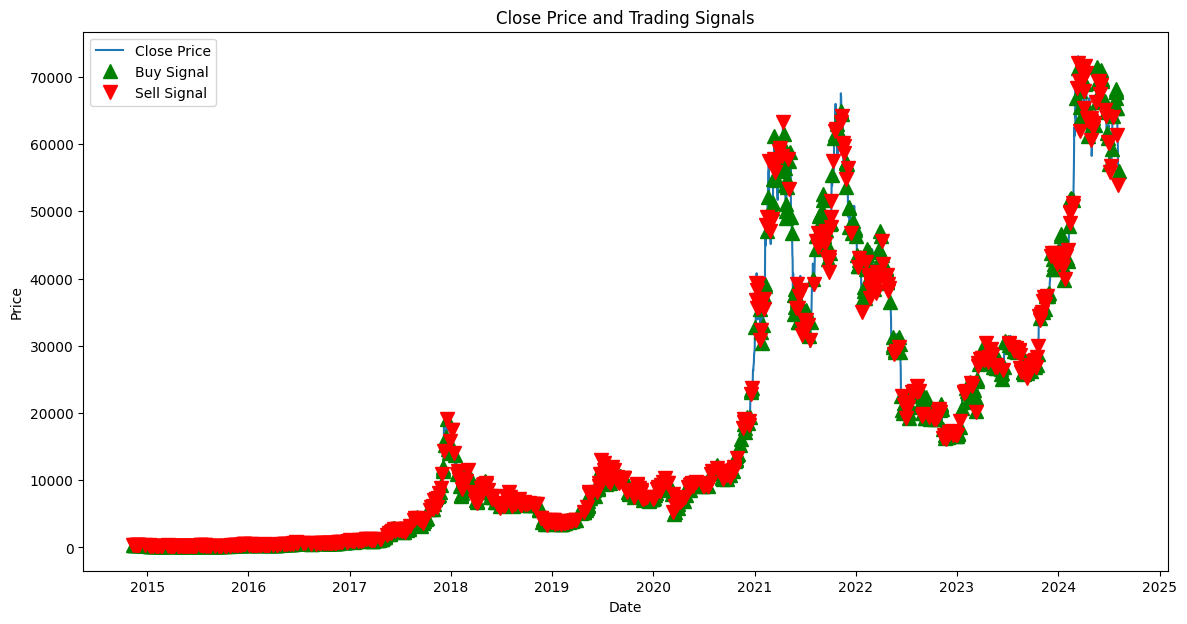

Cumulative Return: 16057.3046875
Max Drawdown: 13293.921875
Sharpe Ratio: 0.12251392390267822


In [ ]:

# Plot the closing prices and positions
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Close Price')
plt.plot(data.loc[data['Position'] == 0].index, data['Close'][data['Position'] == 0], '^', markersize=10, color='g', label='Buy Signal')
plt.plot(data.loc[data['Position'] == 2].index, data['Close'][data['Position'] == 2], 'v', markersize=10, color='r', label='Sell Signal')
plt.title('Close Price and Trading Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Calculate and display performance metrics
cumulative_return = np.sum(rewards)
max_drawdown = np.max(np.maximum.accumulate(rewards) - rewards)
sharpe_ratio = np.mean(rewards) / np.std(rewards) * np.sqrt(252)  # Assuming daily trading
print(f"Cumulative Return: {cumulative_return}")
print(f"Max Drawdown: {max_drawdown}")
print(f"Sharpe Ratio: {sharpe_ratio}")


In [ ]:
# Save the model
model.save("ppo_trading_model")

In [ ]:
# Create the trading environment
env = DummyVecEnv([lambda: TradingEnv(data)])

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [ ]:
model = PPO.load("ppo_trading_model", env=env)


In [ ]:
pip install alpaca-trade-api

In [ ]:
pip install --upgrade alpaca-py


In [ ]:
# import alpaca
# Executing a buy order in Alpaca
def simple_order(qty,symbol='BTC/USD',side="buy",type='market',time_in_force='gtc'):
    from alpaca.trading.client import TradingClient
    from alpaca.trading.requests import MarketOrderRequest
    from alpaca.trading.enums import OrderSide, TimeInForce
    import os

    api_key = 'Your API Key'
    api_secret =  'Your API Secret'
    base_url = 'https://data.sandbox.alpaca.markets/v2'  # for paper trading

    trading_client = TradingClient(api_key, api_secret, paper=True)
    # Setting parameters for our buy order
    market_order_data = MarketOrderRequest(
                          symbol=symbol,
                          qty=qty,
                          side=side,
                          time_in_force=time_in_force,
                          order_class="simple",
                      )
    # Submitting the order and then printing the returned object
    print('Sending order')
    market_order = trading_client.submit_order(market_order_data)


In [ ]:
# Risk management
def calc_share(atr,investment,risk):
  # risk in %
  share_size = investment*risk/100/atr
  return share_size

In [ ]:
from alpaca.trading.client import TradingClient
from alpaca.trading.requests import MarketOrderRequest
from alpaca.trading.enums import OrderSide, TimeInForce

def send_market_order(api_key, secret_key, symbol, qty, side):
    """
    Sends a market order to buy or sell BTC/USD using Alpaca's Paper Trading API.

    :param api_key: Your Alpaca API key.
    :param secret_key: Your Alpaca secret key.
    :param symbol: The trading pair symbol (e.g., 'BTCUSD').
    :param qty: Quantity to buy or sell.
    :param side: 'buy' or 'sell'.
    """
    try:
        # Initialize the TradingClient
        client = TradingClient(api_key, secret_key, paper=True)
        print("Trading client initialized successfully.")

        # Create a market order request
        market_order_data = MarketOrderRequest(
            symbol=symbol,
            qty=qty,
            side=OrderSide.BUY if side.lower() == 'buy' else OrderSide.SELL,
            time_in_force=TimeInForce.DAY
        )
        print(f"Market order created: {market_order_data}")

        # Submit the order
        order = client.submit_order(order_data=market_order_data)
        print(f"Order submitted: {order}")

    except Exception as e:
        print(f"An error occurred: {e}")

# Example usage:
# Replace these with your actual API credentials
api_key = "PK44P7VZJEVZ7AKICL0M"
secret_key = "apSEdrXjEPHvH4S8ghJdpi7XJ0up2PQJELH9XiUM"

# Send a market order to buy 0.01 BTC
send_market_order(api_key, secret_key, 'BTCUSD', 0.01, 'buy')



Trading client initialized successfully.
Market order created: symbol='BTCUSD' qty=0.01 notional=None side=<OrderSide.BUY: 'buy'> type=<OrderType.MARKET: 'market'> time_in_force=<TimeInForce.DAY: 'day'> order_class=None extended_hours=None client_order_id=None take_profit=None stop_loss=None position_intent=None
An error occurred: {"message": "forbidden."}



In [ ]:
def check_account(api_key, secret_key):
    """
    Checks the account details to verify that API credentials are valid.

    :param api_key: Your Alpaca API key.
    :param secret_key: Your Alpaca secret key.
    """
    try:
        # Initialize the TradingClient
        client = TradingClient(api_key, secret_key, paper=True)

        # Get account details
        account = client.get_account()
        print("Account details retrieved successfully:")
        print(account)

    except Exception as e:
        print(f"An error occurred while retrieving account details: {e}")

# Replace these with your actual API credentials
api_key = "PK44P7VZJEVZ7AKICL0M"
secret_key = "apSEdrXjEPHvH4S8ghJdpi7XJ0up2PQJELH9XiUM"

# Check the account
check_account(api_key, secret_key)


An error occurred while retrieving account details: {"message": "forbidden."}

